In [9]:
!pip install -q datasets scikit-learn pandas numpy matplotlib seaborn scipy

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from scipy.stats import pearsonr, spearmanr

import os

In [11]:
dataset = load_dataset("batuhanmtl/job_resume_fit")

print(dataset)

README.md:   0%|          | 0.00/1.36k [00:00<?, ?B/s]

job_resume_fit.csv: reconstructing file:   0%|          |  0.00B / 30.5MB            

job_resume_fit.csv: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/2385 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['ID', 'resume_text', 'job_text', 'category', 'job_required_skills', 'resume_skill_list', 'ai_matched_skills', 'ai_match_score', 'skill_string_match_score', 'fuzzy_match_score'],
        num_rows: 2385
    })
})


In [12]:
df = dataset["train"].to_pandas()

print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (2385, 10)

Columns:
['ID', 'resume_text', 'job_text', 'category', 'job_required_skills', 'resume_skill_list', 'ai_matched_skills', 'ai_match_score', 'skill_string_match_score', 'fuzzy_match_score']


In [13]:
display(df.head())

,ID,resume_text,job_text,category,job_required_skills,resume_skill_list,ai_matched_skills,ai_match_score,skill_string_match_score,fuzzy_match_score
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,Human Resources Business Partner\n------------...,HR,"['human resources management', 'talent acquisi...","['customer service', 'team management', 'marke...","['human resources management', 'employee relat...",49.40,12.50,63.24
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...",Human Resources Business Partner\n------------...,HR,"['human resources management', 'talent acquisi...","['adobe photoshop', 'adp', 'asset management',...","['human resources management', 'talent acquisi...",77.64,16.67,59.07
2,33176873,HR DIRECTOR Summary Over 2...,Human Resources Business Partner\n------------...,HR,"['human resources management', 'talent acquisi...","['recruiting', 'fmla', 'eeo', 'flsa', 'hris de...","['human resources management', 'talent acquisi...",100.00,20.83,61.89
3,27018550,HR SPECIALIST Summary Dedica...,Human Resources Business Partner\n------------...,HR,"['human resources management', 'talent acquisi...","['50 wpm typing', '10-key by touch', 'microsof...","['human resources management', 'employee relat...",32.63,8.33,52.95
4,17812897,HR MANAGER Skill Highlights ...,Human Resources Business Partner\n------------...,HR,"['human resources management', 'talent acquisi...","['hris', 'adp', 'kronos', 'lawson', 'ms office...","['human resources management', 'talent acquisi...",86.03,29.17,64.36


In [14]:
print(df.isnull().sum())

ID                          0
resume_text                 0
job_text                    0
category                    0
job_required_skills         0
resume_skill_list           0
ai_matched_skills           0
ai_match_score              0
skill_string_match_score    0
fuzzy_match_score           0
dtype: int64


In [15]:
text_columns = [
    "resume_text",
    "job_text",
    "job_required_skills",
    "resume_skill_list",
    "ai_matched_skills"
]

for column in text_columns:
    df[column] = df[column].fillna("").astype(str)

In [16]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

In [17]:
df["clean_resume"] = df["resume_text"].apply(clean_text)

df["clean_job"] = df["job_text"].apply(clean_text)

In [18]:
def calculate_tfidf_similarity(resume, job):

    documents = [
        resume,
        job
    ]

    vectorizer = TfidfVectorizer(
        stop_words="english"
    )

    vectors = vectorizer.fit_transform(documents)

    similarity = cosine_similarity(
        vectors[0:1],
        vectors[1:2]
    )[0][0]

    return similarity

In [19]:
df["tfidf_similarity"] = df.apply(
    lambda row: calculate_tfidf_similarity(
        row["clean_resume"],
        row["clean_job"]
    ),
    axis=1
)

In [20]:
df[[
    "ID",
    "tfidf_similarity",
    "ai_match_score",
    "skill_string_match_score",
    "fuzzy_match_score"
]].head(20)

,ID,tfidf_similarity,ai_match_score,skill_string_match_score,fuzzy_match_score
0,16852973,0.154048,49.40,12.50,63.24
1,22323967,0.138482,77.64,16.67,59.07
2,33176873,0.249661,100.00,20.83,61.89
3,27018550,0.107013,32.63,8.33,52.95
4,17812897,0.397116,86.03,29.17,64.36
5,11592605,0.153740,73.15,16.67,58.22
6,25824789,0.207796,71.36,29.17,64.29
7,15375009,0.218364,86.03,8.33,56.12
8,11847784,0.218365,95.81,25.00,65.34
9,32896934,0.306343,90.92,33.33,64.88


In [21]:
print("TF-IDF range:")
print(df["tfidf_similarity"].min(),
      df["tfidf_similarity"].max())

print("\nAI match range:")
print(df["ai_match_score"].min(),
      df["ai_match_score"].max())

print("\nString match range:")
print(df["skill_string_match_score"].min(),
      df["skill_string_match_score"].max())

print("\nFuzzy match range:")
print(df["fuzzy_match_score"].min(),
      df["fuzzy_match_score"].max())

TF-IDF range:
0.0 0.5572154870487613

AI match range:
0.0 100.0

String match range:
0.0 41.67

Fuzzy match range:
26.15 84.41


In [22]:
from sklearn.preprocessing import MinMaxScaler

score_columns = [
    "ai_match_score",
    "skill_string_match_score",
    "fuzzy_match_score"
]

scaler = MinMaxScaler()

df[
    [column + "_normalized" for column in score_columns]
] = scaler.fit_transform(
    df[score_columns]
)

In [23]:
df[[
    "ID",
    "tfidf_similarity",
    "ai_match_score_normalized",
    "skill_string_match_score_normalized",
    "fuzzy_match_score_normalized"
]].head(20)

,ID,tfidf_similarity,ai_match_score_normalized,skill_string_match_score_normalized,fuzzy_match_score_normalized
0,16852973,0.154048,0.4940,0.299976,0.636629
1,22323967,0.138482,0.7764,0.400048,0.565053
2,33176873,0.249661,1.0000,0.499880,0.613457
3,27018550,0.107013,0.3263,0.199904,0.460007
4,17812897,0.397116,0.8603,0.700024,0.655853
5,11592605,0.153740,0.7315,0.400048,0.550463
6,25824789,0.207796,0.7136,0.700024,0.654652
7,15375009,0.218364,0.8603,0.199904,0.514418
8,11847784,0.218365,0.9581,0.599952,0.672674
9,32896934,0.306343,0.9092,0.799856,0.664779


In [24]:
df["baseline_merit_score"] = (
    0.50 * df["tfidf_similarity"]
    + 0.30 * df["skill_string_match_score_normalized"]
    + 0.20 * df["fuzzy_match_score_normalized"]
)

In [25]:
df["baseline_merit_percentage"] = (
    df["baseline_merit_score"] * 100
)

In [26]:
df["rank"] = (
    df["baseline_merit_score"]
    .rank(
        ascending=False,
        method="first"
    )
    .astype(int)
)

In [27]:
top_candidates = df.sort_values(
    by="baseline_merit_score",
    ascending=False
).head(20)

display(
    top_candidates[[
        "ID",
        "category",
        "baseline_merit_percentage",
        "tfidf_similarity",
        "skill_string_match_score_normalized",
        "fuzzy_match_score_normalized"
    ]]
)

,ID,category,baseline_merit_percentage,tfidf_similarity,skill_string_match_score_normalized,fuzzy_match_score_normalized
2003,75329822,PUBLIC-RELATIONS,69.275999,0.499734,0.899928,0.864573
1967,27257013,PUBLIC-RELATIONS,69.071191,0.521453,0.899928,0.800034
1999,16226743,PUBLIC-RELATIONS,66.450543,0.378788,1.000000,0.875558
1430,29775391,CHEF,64.939176,0.456156,0.942885,0.692242
656,91467795,BUSINESS-DEVELOPMENT,61.536672,0.398231,0.880010,0.761243
1949,10070224,PUBLIC-RELATIONS,61.146550,0.385412,0.899928,0.743907
101,28175164,HR,61.050139,0.431717,0.799856,0.773429
2162,11266906,BANKING,60.689555,0.283083,0.959923,0.886886
105,30563572,HR,60.399825,0.416926,0.799856,0.777892
1491,84356308,FINANCE,60.346595,0.448167,0.776338,0.732406


In [28]:
pearson_ai = pearsonr(
    df["tfidf_similarity"],
    df["ai_match_score_normalized"]
)

pearson_string = pearsonr(
    df["tfidf_similarity"],
    df["skill_string_match_score_normalized"]
)

pearson_fuzzy = pearsonr(
    df["tfidf_similarity"],
    df["fuzzy_match_score_normalized"]
)

print("TF-IDF vs AI Match:")
print("Correlation:", pearson_ai.statistic)
print("p-value:", pearson_ai.pvalue)

print("\nTF-IDF vs String Match:")
print("Correlation:", pearson_string.statistic)
print("p-value:", pearson_string.pvalue)

print("\nTF-IDF vs Fuzzy Match:")
print("Correlation:", pearson_fuzzy.statistic)
print("p-value:", pearson_fuzzy.pvalue)

TF-IDF vs AI Match:
Correlation: 0.6832281723978326
p-value: 0.0

TF-IDF vs String Match:
Correlation: 0.5251413493065147
p-value: 3.4118220929557e-169

TF-IDF vs Fuzzy Match:
Correlation: 0.6019657037334157
p-value: 3.828374564022381e-235


In [29]:
spearman_ai = spearmanr(
    df["tfidf_similarity"],
    df["ai_match_score_normalized"]
)

spearman_string = spearmanr(
    df["tfidf_similarity"],
    df["skill_string_match_score_normalized"]
)

spearman_fuzzy = spearmanr(
    df["tfidf_similarity"],
    df["fuzzy_match_score_normalized"]
)

print("TF-IDF vs AI Match:")
print("Spearman:", spearman_ai.statistic)

print("\nTF-IDF vs String Match:")
print("Spearman:", spearman_string.statistic)

print("\nTF-IDF vs Fuzzy Match:")
print("Spearman:", spearman_fuzzy.statistic)

TF-IDF vs AI Match:
Spearman: 0.6949401205363501

TF-IDF vs String Match:
Spearman: 0.519252917726197

TF-IDF vs Fuzzy Match:
Spearman: 0.6118293385142025


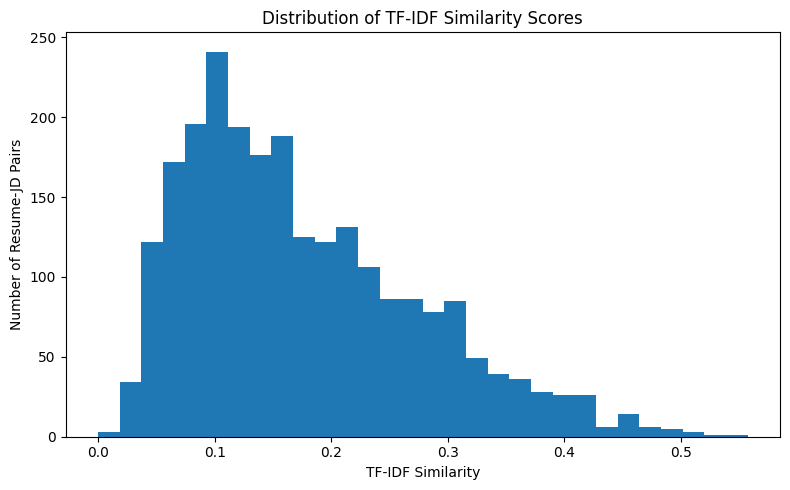

In [30]:
plt.figure(figsize=(8, 5))

plt.hist(
    df["tfidf_similarity"],
    bins=30
)

plt.xlabel("TF-IDF Similarity")
plt.ylabel("Number of Resume-JD Pairs")
plt.title("Distribution of TF-IDF Similarity Scores")

plt.tight_layout()
plt.show()

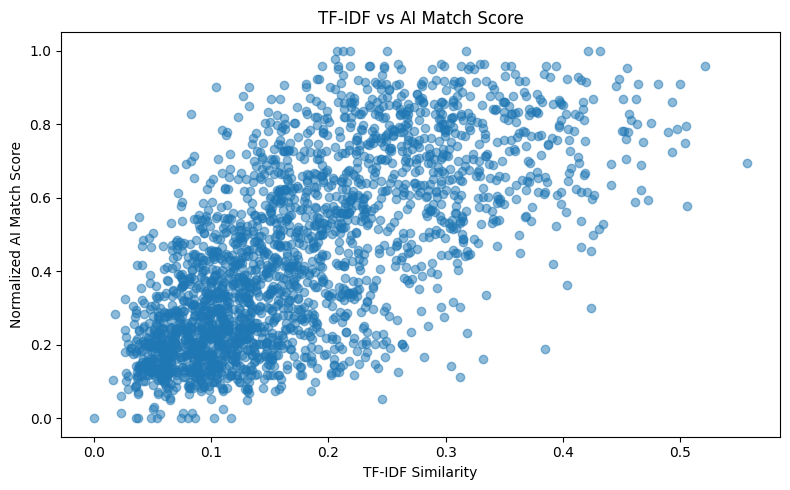

In [31]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["tfidf_similarity"],
    df["ai_match_score_normalized"],
    alpha=0.5
)

plt.xlabel("TF-IDF Similarity")
plt.ylabel("Normalized AI Match Score")
plt.title("TF-IDF vs AI Match Score")

plt.tight_layout()
plt.show()

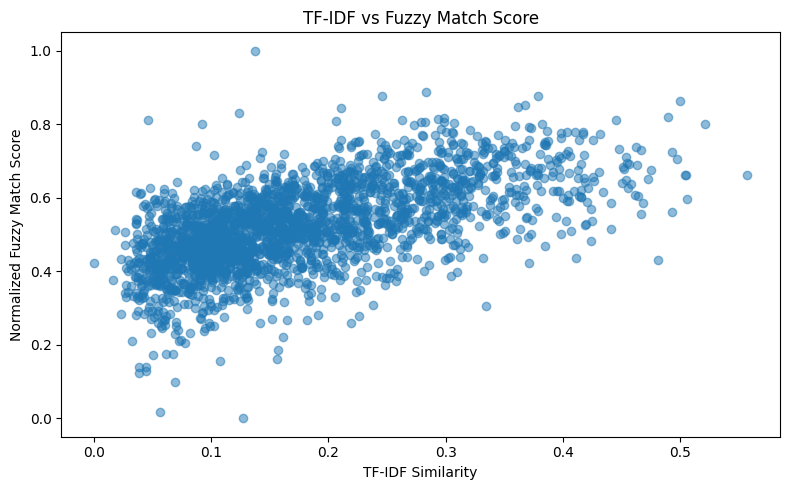

In [32]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["tfidf_similarity"],
    df["fuzzy_match_score_normalized"],
    alpha=0.5
)

plt.xlabel("TF-IDF Similarity")
plt.ylabel("Normalized Fuzzy Match Score")
plt.title("TF-IDF vs Fuzzy Match Score")

plt.tight_layout()
plt.show()

In [33]:
category_summary = (
    df.groupby("category")[
        "tfidf_similarity"
    ]
    .agg(
        ["mean", "min", "max", "count"]
    )
    .sort_values(
        by="mean",
        ascending=False
    )
)

category_summary

,mean,min,max,count
category,,,,
CONSTRUCTION,0.261015,0.055971,0.557215,112
BUSINESS-DEVELOPMENT,0.256331,0.000000,0.463053,120
FINANCE,0.249889,0.060348,0.504161,118
CHEF,0.237155,0.032434,0.462553,118
HR,0.220645,0.078180,0.431717,110
PUBLIC-RELATIONS,0.213704,0.034449,0.521453,111
TEACHER,0.199345,0.046833,0.425439,102
DIGITAL-MEDIA,0.192023,0.026193,0.441203,96
FITNESS,0.191926,0.041167,0.472735,117


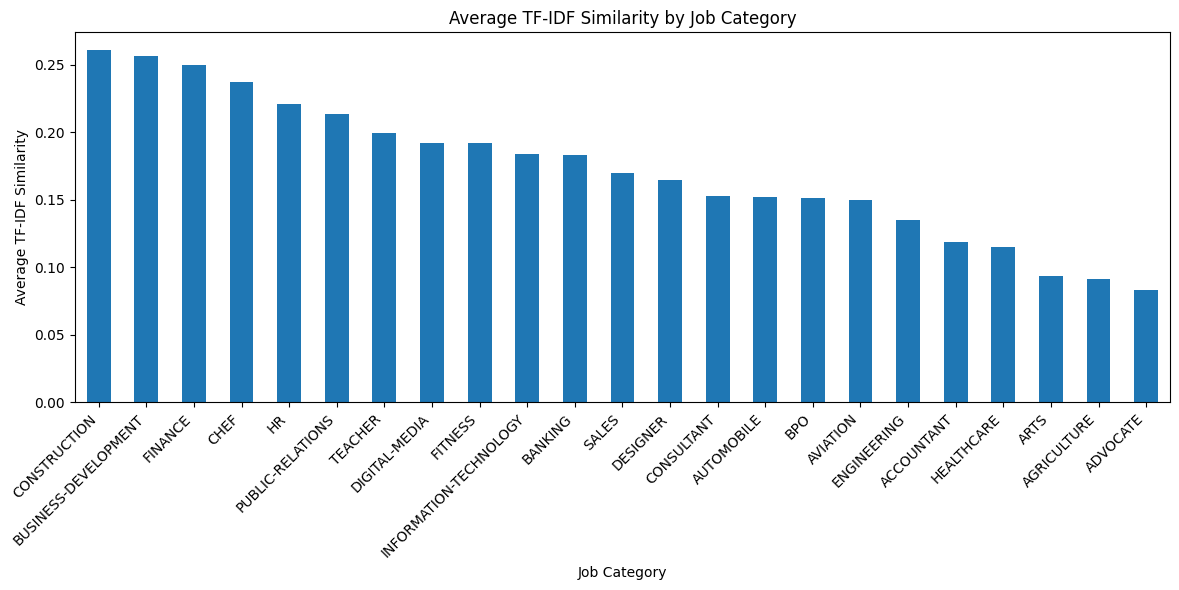

In [34]:
plt.figure(figsize=(12, 6))

category_summary["mean"].plot(
    kind="bar"
)

plt.xlabel("Job Category")
plt.ylabel("Average TF-IDF Similarity")
plt.title("Average TF-IDF Similarity by Job Category")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [35]:
os.makedirs(
    "phase1_results",
    exist_ok=True
)

In [36]:
df.to_csv(
    "phase1_results/phase1_complete_results.csv",
    index=False
)

In [37]:
top_candidates.to_csv(
    "phase1_results/top_candidates.csv",
    index=False
)

In [38]:
category_summary.to_csv(
    "phase1_results/category_summary.csv"
)

In [39]:
print("=" * 60)
print("PHASE 1 — TF-IDF RESUME SCREENING")
print("=" * 60)

print("\nNumber of resume-JD pairs:", len(df))

print(
    "Average TF-IDF similarity:",
    round(df["tfidf_similarity"].mean(), 4)
)

print(
    "Maximum TF-IDF similarity:",
    round(df["tfidf_similarity"].max(), 4)
)

print(
    "Minimum TF-IDF similarity:",
    round(df["tfidf_similarity"].min(), 4)
)

print(
    "\nHighest scoring pair ID:",
    df.loc[
        df["baseline_merit_score"].idxmax(),
        "ID"
    ]
)

print(
    "\nOutput files:"
)

for file in os.listdir("phase1_results"):
    print(" -", file)

PHASE 1 — TF-IDF RESUME SCREENING

Number of resume-JD pairs: 2385
Average TF-IDF similarity: 0.1758
Maximum TF-IDF similarity: 0.5572
Minimum TF-IDF similarity: 0.0

Highest scoring pair ID: 75329822

Output files:
 - category_summary.csv
 - top_candidates.csv
 - phase1_complete_results.csv
